In [2]:
# Section 1: Imports & environment setup
import os
import sys
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
sns.set(style="whitegrid")
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

# Helper to create outputs folder
PROJECT_ROOT = Path(os.getcwd())
OUT_DIR = PROJECT_ROOT / 'outputs'
OUT_DIR.mkdir(exist_ok=True)
print('Project root:', PROJECT_ROOT)
print('Outputs folder:', OUT_DIR)

# Optional: show versions (uncomment if you want)
# import sklearn, xgboost, joblib, shap
# print('pandas', pd.__version__, 'numpy', np.__version__)

Project root: c:\Users\ahmed\OneDrive\Desktop\projet_data
Outputs folder: c:\Users\ahmed\OneDrive\Desktop\projet_data\outputs


## 2. Chargement de la base


In [61]:
from pathlib import Path


# Charger le CSV principal
data_path = Path("C:/Users/ahmed/OneDrive/Desktop/projet_data/data/bank-additional-full.csv") 

master = pd.read_csv(data_path, sep=None, engine='python')

# Vérifier les premières lignes
display(master.head())

print(master.info())
print(master.describe())
master['id'] = master.index + 1

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
0,56,housemaid,married,basic.4y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
1,57,services,married,high.school,unknown,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
2,37,services,married,high.school,no,yes,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
3,40,admin.,married,basic.6y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
4,56,services,married,high.school,no,no,yes,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 41188 entries, 0 to 41187
Data columns (total 21 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   age             41188 non-null  int64  
 1   job             41188 non-null  object 
 2   marital         41188 non-null  object 
 3   education       41188 non-null  object 
 4   default         41188 non-null  object 
 5   housing         41188 non-null  object 
 6   loan            41188 non-null  object 
 7   contact         41188 non-null  object 
 8   month           41188 non-null  object 
 9   day_of_week     41188 non-null  object 
 10  duration        41188 non-null  int64  
 11  campaign        41188 non-null  int64  
 12  pdays           41188 non-null  int64  
 13  previous        41188 non-null  int64  
 14  poutcome        41188 non-null  object 
 15  emp.var.rate    41188 non-null  float64
 16  cons.price.idx  41188 non-null  float64
 17  cons.conf.idx   41188 non-null 

### 3 Résumé des colonnes : générer automatiquement un tableau avec type, utilité, importance pour prédiction et observations :


In [63]:
cols = master.columns.tolist()
dtypes = master.dtypes.astype(str).to_dict()

cols_df = pd.DataFrame([{'col': c, 'dtype': str(master[c].dtype)} for c in cols])
display(cols_df)

,col,dtype
0,age,int64
1,job,object
2,marital,object
3,education,object
4,default,object
5,housing,object
6,loan,object
7,contact,object
8,month,object
9,day_of_week,object


In [64]:
cols_summary = [
    {'col': 'age', 'dtype': 'int', 'utilité': 'Distribution des âges', 'importance': 'Forte', 'remarque': 'Vérifier présence d’âges extrêmes'},
    {'col': 'job', 'dtype': 'cat', 'utilité': 'Répartition par profession', 'importance': 'Moyenne à forte', 'remarque': 'Encodage catégoriel nécessaire'},
    {'col': 'marital', 'dtype': 'cat', 'utilité': 'Statut marital, analyse socio-démographique', 'importance': 'Moyenne', 'remarque': 'Regrouper éventuellement en couples / célibataires'},
    {'col': 'education', 'dtype': 'cat', 'utilité': 'Niveau d’éducation des clients', 'importance': 'Moyenne', 'remarque': 'Harmoniser les libellés, gérer les “unknown”'},
    {'col': 'default', 'dtype': 'cat', 'utilité': 'Historique de défaut de paiement', 'importance': 'Forte', 'remarque': 'Traiter valeurs inconnues (“unknown”)'},
    {'col': 'housing', 'dtype': 'cat', 'utilité': 'Possession d’un crédit immobilier', 'importance': 'Moyenne', 'remarque': 'Encodage nécessaire'},
    {'col': 'loan', 'dtype': 'cat', 'utilité': 'Possession d’un prêt personnel', 'importance': 'Moyenne', 'remarque': 'Encodage nécessaire'},
    {'col': 'contact', 'dtype': 'cat', 'utilité': 'Canal de communication', 'importance': 'Faible à moyenne', 'remarque': 'Peut aider à comprendre efficacité des campagnes'},
    {'col': 'month', 'dtype': 'cat', 'utilité': 'Mois du dernier contact', 'importance': 'Faible à moyenne', 'remarque': 'Encodage cyclique possible pour capturer saisonnalité'},
    {'col': 'day_of_week', 'dtype': 'cat', 'utilité': 'Jour de la semaine du dernier contact', 'importance': 'Faible à moyenne', 'remarque': 'Encodage cyclique possible'},
    {'col': 'duration', 'dtype': 'int', 'utilité': 'Durée du dernier contact (en secondes)', 'importance': 'Très forte', 'remarque': 'Attention : fuite de donnée possible si utilisé tel quel'},
    {'col': 'campaign', 'dtype': 'int', 'utilité': 'Nombre de contacts lors de la campagne', 'importance': 'Moyenne', 'remarque': 'Vérifier valeurs extrêmes'},
    {'col': 'pdays', 'dtype': 'int', 'utilité': 'Jours depuis le dernier contact précédent', 'importance': 'Moyenne', 'remarque': '999 indique “pas de contact précédent”, à gérer'},
    {'col': 'previous', 'dtype': 'int', 'utilité': 'Nombre de contacts antérieurs', 'importance': 'Moyenne', 'remarque': 'Utile pour le comportement client'},
    {'col': 'poutcome', 'dtype': 'cat', 'utilité': 'Résultat de la campagne précédente', 'importance': 'Forte', 'remarque': 'Catégorie clé (“success”, “failure”, “other”)'},
    {'col': 'emp.var.rate', 'dtype': 'float', 'utilité': 'Taux de variation de l’emploi', 'importance': 'Faible à moyenne', 'remarque': 'Macro-économie, influence possible sur souscription'},
    {'col': 'cons.price.idx', 'dtype': 'float', 'utilité': 'Indice des prix à la consommation', 'importance': 'Faible à moyenne', 'remarque': 'Macro-économie'},
    {'col': 'cons.conf.idx', 'dtype': 'float', 'utilité': 'Indice de confiance des consommateurs', 'importance': 'Faible à moyenne', 'remarque': 'Macro-économie'},
    {'col': 'euribor3m', 'dtype': 'float', 'utilité': 'Taux Euribor 3 mois', 'importance': 'Moyenne', 'remarque': 'Influence les décisions financières'},
    {'col': 'nr.employed', 'dtype': 'float', 'utilité': 'Nombre d’employés', 'importance': 'Faible à moyenne', 'remarque': 'Macro-économie, tendance générale'},
    {'col': 'y', 'dtype': 'cat', 'utilité': 'Variable cible : souscription oui/non', 'importance': 'Très forte', 'remarque': 'À prédire, encoder “yes”=1 / “no”=0'}
]
cols_df = pd.DataFrame(cols_summary)
cols_df.to_csv(Path('outputs')/'columns_summary.csv', index=False)
display(cols_df)

,col,dtype,utilité,importance,remarque
0,age,int,Distribution des âges,Forte,Vérifier présence d’âges extrêmes
1,job,cat,Répartition par profession,Moyenne à forte,Encodage catégoriel nécessaire
2,marital,cat,"Statut marital, analyse socio-démographique",Moyenne,Regrouper éventuellement en couples / célibata...
3,education,cat,Niveau d’éducation des clients,Moyenne,"Harmoniser les libellés, gérer les “unknown”"
4,default,cat,Historique de défaut de paiement,Forte,Traiter valeurs inconnues (“unknown”)
5,housing,cat,Possession d’un crédit immobilier,Moyenne,Encodage nécessaire
6,loan,cat,Possession d’un prêt personnel,Moyenne,Encodage nécessaire
7,contact,cat,Canal de communication,Faible à moyenne,Peut aider à comprendre efficacité des campagnes
8,month,cat,Mois du dernier contact,Faible à moyenne,Encodage cyclique possible pour capturer saiso...
9,day_of_week,cat,Jour de la semaine du dernier contact,Faible à moyenne,Encodage cyclique possible


## 4. Prétraitement :


In [65]:
# Remplacer 'unknown' par np.nan pour toutes les colonnes catégorielles
import numpy as np


def standardize_missing(df):
    df = df.copy()
    for c in df.select_dtypes(include=['object']).columns:
        df[c] = df[c].replace('unknown', np.nan)
        df[c] = df[c].replace('nonexistent', np.nan)
    return df

master_clean = standardize_missing(master)
print("Missing per column (top 10):")
display(master_clean.isna().sum().sort_values(ascending=False).head(10))

Missing per column (top 10):


poutcome     35563
default       8597
education     1731
housing        990
loan           990
job            330
marital         80
age              0
month            0
contact          0
dtype: int64

## 5. Découpage en groupes de colonnes : profil, campagne, macro-économie:


In [ ]:
profil_cols = ['id','age','job','marital','education','default','housing','loan']
campagne_cols = ['id', 'contact','month','day_of_week','duration','campaign','pdays','previous','poutcome','y']
macro_cols = ['id', 'emp.var.rate','cons.price.idx','cons.conf.idx','euribor3m','nr.employed']
finance = ['id', 'balance', 'day', 'month']

profil_cols = [c for c in profil_cols if c in master_clean.columns]
campagne_cols = [c for c in campagne_cols if c in master_clean.columns]
macro_cols = [c for c in macro_cols if c in master_clean.columns]

df_profil = master_clean[profil_cols].copy()
df_campagne = master_clean[campagne_cols].copy()
df_macro = master_clean[macro_cols].copy()


print("Profil cols:", profil_cols)
print("Campagne cols:", campagne_cols)
print("Macro cols:", macro_cols)


,id,age,job,marital,education,default,housing,loan
0,1,56,housemaid,married,basic.4y,no,no,no
1,2,57,services,married,high.school,NaN,no,no
2,3,37,services,married,high.school,no,yes,no
3,4,40,admin.,married,basic.6y,no,no,no
4,5,56,services,married,high.school,no,no,yes
...,...,...,...,...,...,...,...,...
41183,41184,73,retired,married,professional.course,no,yes,no
41184,41185,46,blue-collar,married,professional.course,no,no,no
41185,41186,56,retired,married,university.degree,no,yes,no
41186,41187,44,technician,married,professional.course,no,no,no


,id,contact,month,day_of_week,duration,campaign,pdays,previous,poutcome,y
0,1,telephone,may,mon,261,1,999,0,NaN,no
1,2,telephone,may,mon,149,1,999,0,NaN,no
2,3,telephone,may,mon,226,1,999,0,NaN,no
3,4,telephone,may,mon,151,1,999,0,NaN,no
4,5,telephone,may,mon,307,1,999,0,NaN,no
...,...,...,...,...,...,...,...,...,...,...
41183,41184,cellular,nov,fri,334,1,999,0,NaN,yes
41184,41185,cellular,nov,fri,383,1,999,0,NaN,no
41185,41186,cellular,nov,fri,189,2,999,0,NaN,no
41186,41187,cellular,nov,fri,442,1,999,0,NaN,yes


,id,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed
0,1,1.1,93.994,-36.4,4.857,5191.0
1,2,1.1,93.994,-36.4,4.857,5191.0
2,3,1.1,93.994,-36.4,4.857,5191.0
3,4,1.1,93.994,-36.4,4.857,5191.0
4,5,1.1,93.994,-36.4,4.857,5191.0
...,...,...,...,...,...,...
41183,41184,-1.1,94.767,-50.8,1.028,4963.6
41184,41185,-1.1,94.767,-50.8,1.028,4963.6
41185,41186,-1.1,94.767,-50.8,1.028,4963.6
41186,41187,-1.1,94.767,-50.8,1.028,4963.6


Profil cols: ['id', 'age', 'job', 'marital', 'education', 'default', 'housing', 'loan']
Campagne cols: ['id', 'contact', 'month', 'day_of_week', 'duration', 'campaign', 'pdays', 'previous', 'poutcome', 'y']
Macro cols: ['id', 'emp.var.rate', 'cons.price.idx', 'cons.conf.idx', 'euribor3m', 'nr.employed']


## 6. Feature engineering (exemples)

In [73]:
df = master_clean.copy()

# ---------------------------------------------------------
# 2) Binning d'âge : transformer la variable continue "age"
# en catégories (groupes d'âge) tout en gardant la variable originale.
# ---------------------------------------------------------
age_bins = [0, 25, 35, 50, 65, 120]
age_labels = ['<25','25-34','35-49','50-64','65+']
df['age_bin'] = pd.cut(
    df['age'],
    bins=age_bins,
    labels=age_labels,
    include_lowest=True
)

# ---------------------------------------------------------
# 3) Variable "pdays" :
# - 'pdays_never_contacted' = 1 si jamais contacté (coded 999)
# - 'pdays_since' = remplace 999 par NaN pour une future analyse
# ---------------------------------------------------------
if 'pdays' in df.columns:
    df['pdays_never_contacted'] = (df['pdays'] == 999).astype(int)
    df['pdays_since'] = df['pdays'].replace(999, np.nan)

# ---------------------------------------------------------
# 4) Transformations logarithmiques sur 'duration'
# Réduit l'asymétrie de la distribution
# ---------------------------------------------------------
if 'duration' in df.columns:
    df['duration_log1p'] = np.log1p(df['duration'])

# ---------------------------------------------------------
# 5) Variables temporelles : mois → nombre, trimestre, saison
# ---------------------------------------------------------
if 'month' in df.columns:
    month_map = {
        'jan':1,'feb':2,'mar':3,'apr':4,'may':5,'jun':6,
        'jul':7,'aug':8,'sep':9,'oct':10,'nov':11,'dec':12
    }
    df['month_num'] = df['month'].map(month_map)

    # Extrait le trimestre (1 -> Hiver, 2 -> Printemps, ...)
    df['quarter'] = pd.to_datetime(df['month_num'], format='%m', errors='coerce').dt.quarter

    # Saison approximative
    df['season'] = df['quarter'].map({
        1:'winter', 2:'spring', 3:'summer', 4:'autumn'
    })

# ---------------------------------------------------------
# 6) Interaction simple : jeune + appel court
# Objectif : capturer un pattern potentiel
# ---------------------------------------------------------
if 'age' in df.columns and 'duration' in df.columns:
    df['young_short_call'] = (
        (df['age'] < 35) &
        (df['duration'] < df['duration'].median())
    ).astype(int)

# ---------------------------------------------------------
# 7) Encodage ordinal de l'éducation
# (ordre logique que tu peux adapter si besoin)
# ---------------------------------------------------------
if 'education' in df.columns:
    edu_order = [
        'illiterate','basic.4y','basic.6y','basic.9y',
        'high.school','university.degree','professional.course'
    ]
    df['education_ord'] = (
        df['education']
        .astype(pd.CategoricalDtype(categories=edu_order, ordered=True))
        .cat.codes
        .replace(-1, np.nan)
    )

# ---------------------------------------------------------
# 8) Variable cible binaire
# ('yes' -> 1 , 'no' -> 0)
# ---------------------------------------------------------
if 'y' in df.columns:
    df['y_bin'] = df['y'].map({'yes':1,'no':0})

# ---------------------------------------------------------
# 9) Aperçu rapide des colonnes créées
# ---------------------------------------------------------
created_cols = [
    c for c in df.columns
    if (
        c.endswith('_bin') or
        c.endswith('_since') or
        c in [
            'age_bin','month_num','quarter','season',
            'young_short_call','education_ord',
            'pdays_never_contacted','duration_log1p'
        ]
    )
]

print("Colonnes créées :", created_cols)

df.head()[[
    c for c in [
        'age','age_bin','pdays','pdays_never_contacted','pdays_since',
        'duration','duration_log1p','month','month_num','season',
        'young_short_call','education','education_ord','y','y_bin'
    ] if c in df.columns
]]
df.to_csv(Path('outputs')/'up_data.csv', index=False)
display(df)

Colonnes créées : ['age_bin', 'pdays_never_contacted', 'pdays_since', 'duration_log1p', 'month_num', 'quarter', 'season', 'young_short_call', 'education_ord', 'y_bin']


,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,age_bin,pdays_never_contacted,pdays_since,duration_log1p,month_num,quarter,season,young_short_call,education_ord,y_bin
0,56,housemaid,married,basic.4y,no,no,no,telephone,may,mon,...,50-64,1,NaN,5.568345,5,2,spring,0,1.0,0
1,57,services,married,high.school,NaN,no,no,telephone,may,mon,...,50-64,1,NaN,5.010635,5,2,spring,0,4.0,0
2,37,services,married,high.school,no,yes,no,telephone,may,mon,...,35-49,1,NaN,5.424950,5,2,spring,0,4.0,0
3,40,admin.,married,basic.6y,no,no,no,telephone,may,mon,...,35-49,1,NaN,5.023881,5,2,spring,0,2.0,0
4,56,services,married,high.school,no,no,yes,telephone,may,mon,...,50-64,1,NaN,5.730100,5,2,spring,0,4.0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
41183,73,retired,married,professional.course,no,yes,no,cellular,nov,fri,...,65+,1,NaN,5.814131,11,4,autumn,0,6.0,1
41184,46,blue-collar,married,professional.course,no,no,no,cellular,nov,fri,...,35-49,1,NaN,5.950643,11,4,autumn,0,6.0,0
41185,56,retired,married,university.degree,no,yes,no,cellular,nov,fri,...,50-64,1,NaN,5.247024,11,4,autumn,0,5.0,0
41186,44,technician,married,professional.course,no,no,no,cellular,nov,fri,...,35-49,1,NaN,6.093570,11,4,autumn,0,6.0,1


In [ ]:
# --- Définition des groupes de colonnes ---

profil_client = ['id',
    'age', 'age_bin', 'job', 'marital', 'education', 'education_ord',
    'young_short_call'
]

campagne_historique = ['id',
    'campaign', 'previous', 'poutcome',
    'pdays', 'pdays_since', 'pdays_never_contacted',
    'duration', 'duration_log1p',
    'month', 'month_num', 'quarter', 'season'
]

finance = ['id',
    'balance', 'housing', 'loan', 'default'
]

ind_macro = [ 'id',
    'emp.var.rate', 'cons.price.idx', 'cons.conf.idx', 'euribor3m', 'nr.employed'
]

# --- Filtrer selon les colonnes réellement présentes dans df ---

profil_client = [c for c in profil_client if c in df.columns]
campagne_historique = [c for c in campagne_historique if c in df.columns]
finance = [c for c in finance if c in df.columns]
ind_macro = [c for c in ind_macro if c in df.columns]

df_profil = df[profil_client].copy()
df_campagne = df[campagne_historique].copy()
df_macro = df[ind_macro].copy()
df_finace = df[finance].copy()



profil = pd.DataFrame(df_profil)
profil.to_csv(Path('outputs')/'profil_cols.csv', index=False)
display(profil)
compagne = pd.DataFrame(df_campagne)
compagne.to_csv(Path('outputs')/'campagne_cols.csv', index=False)
display(compagne)
macro = pd.DataFrame(df_macro)
macro.to_csv(Path('outputs')/'macro_cols.csv', index=False)
display(macro)
finance = pd.DataFrame(df_macro)
finance.to_csv(Path('outputs')/'macro_cols.csv', index=False)
display(finance)

print("Profil client :", profil_client)
print("Campagne / Historique :", campagne_historique)
print("Finance :", finance)
print("Indicateurs macroéconomiques :", ind_macro)

Profil client : ['age', 'age_bin', 'job', 'marital', 'education', 'education_ord', 'young_short_call']
Campagne / Historique : ['campaign', 'previous', 'poutcome', 'pdays', 'pdays_since', 'pdays_never_contacted', 'duration', 'duration_log1p', 'month', 'month_num', 'quarter', 'season']
Finance : ['housing', 'loan', 'default']
Indicateurs macroéconomiques : ['emp.var.rate', 'cons.price.idx', 'cons.conf.idx', 'euribor3m', 'nr.employed']


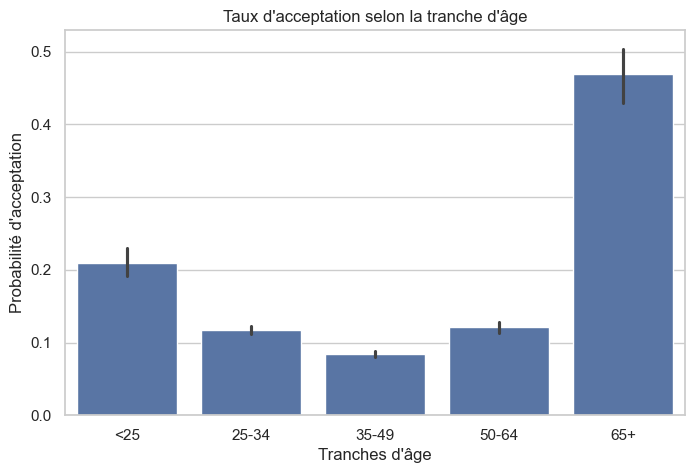

In [46]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
sns.barplot(data=df, x='age_bin', y='y_bin')
plt.title("Taux d'acceptation selon la tranche d'âge")
plt.ylabel("Probabilité d'acceptation")
plt.xlabel("Tranches d'âge")
plt.show()


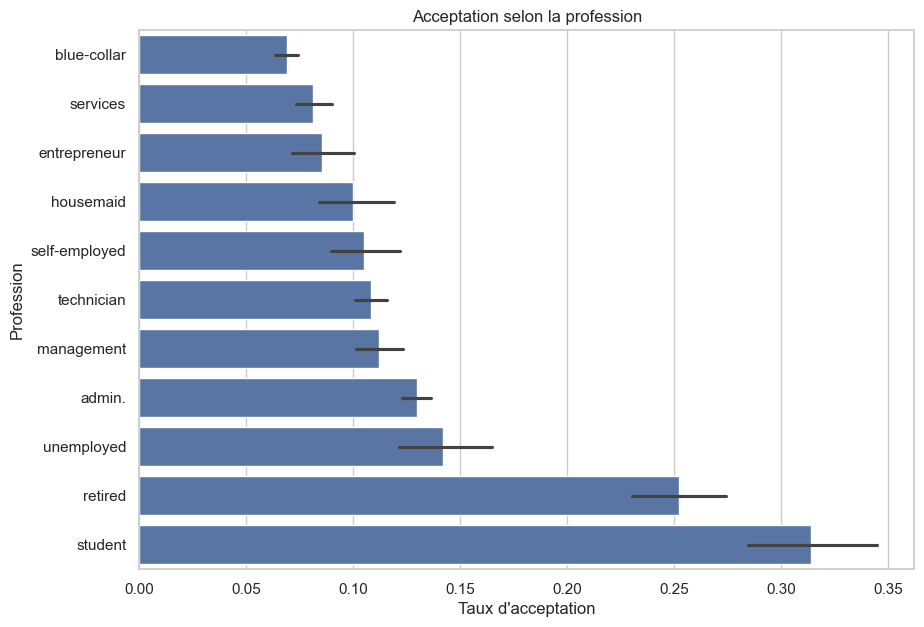

In [47]:
plt.figure(figsize=(10,7))
sns.barplot(
    data=df,
    y='job',
    x='y_bin',
    order=df.groupby('job')['y_bin'].mean().sort_values().index
)
plt.title("Acceptation selon la profession")
plt.xlabel("Taux d'acceptation")
plt.ylabel("Profession")
plt.show()


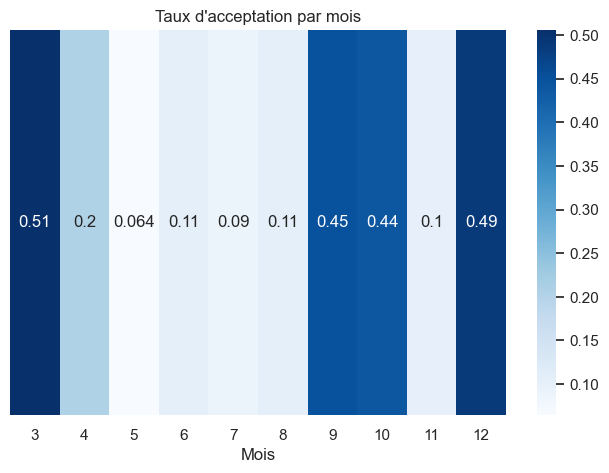

In [48]:
tmp = df.groupby(['month_num'])['y_bin'].mean()

plt.figure(figsize=(8,5))
sns.heatmap(tmp.to_frame().T, annot=True, cmap="Blues")
plt.title("Taux d'acceptation par mois")
plt.yticks([])
plt.xlabel("Mois")
plt.show()


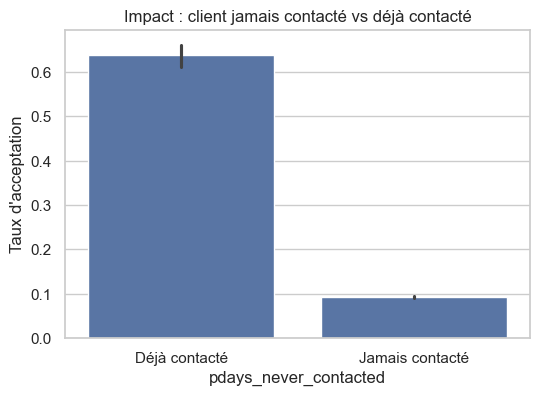

In [49]:
plt.figure(figsize=(6,4))
sns.barplot(
    data=df,
    x='pdays_never_contacted',
    y='y_bin'
)
plt.title("Impact : client jamais contacté vs déjà contacté")
plt.xticks([0,1], ["Déjà contacté", "Jamais contacté"])
plt.ylabel("Taux d'acceptation")
plt.show()


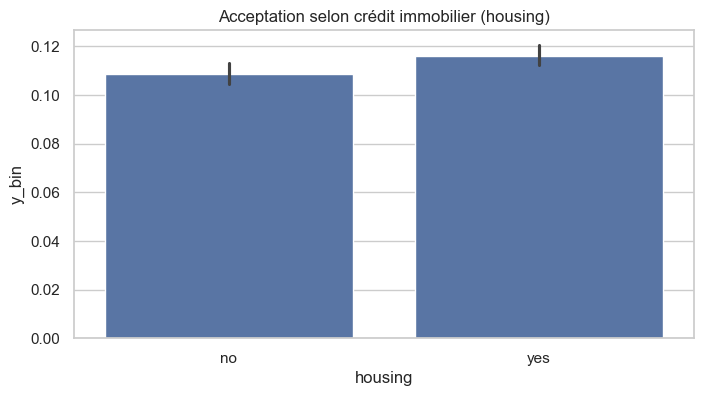

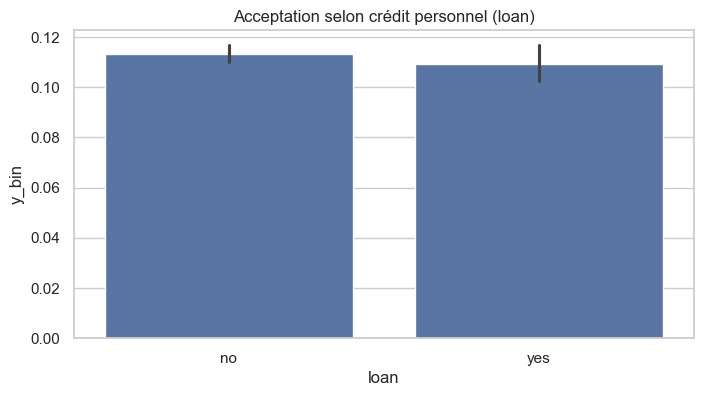

In [50]:
plt.figure(figsize=(8,4))
sns.barplot(data=df, x='housing', y='y_bin')
plt.title("Acceptation selon crédit immobilier (housing)")
plt.show()

plt.figure(figsize=(8,4))
sns.barplot(data=df, x='loan', y='y_bin')
plt.title("Acceptation selon crédit personnel (loan)")
plt.show()


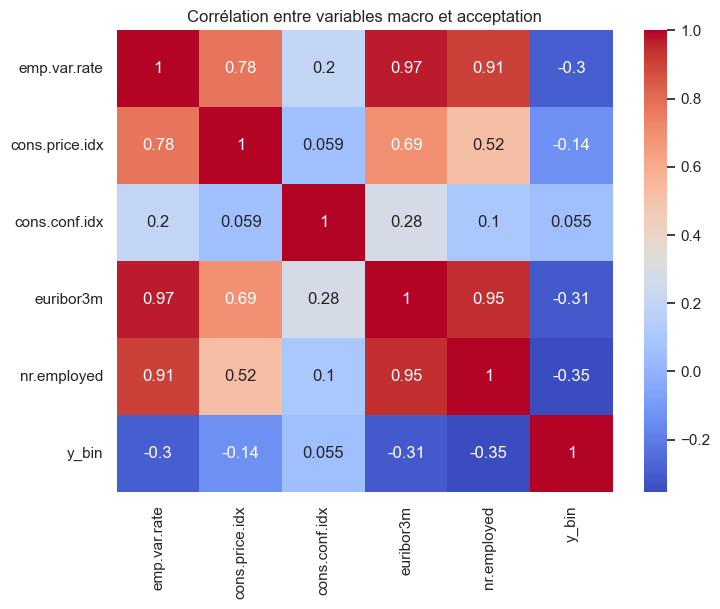

In [51]:
plt.figure(figsize=(8,6))
sns.heatmap(df[ind_macro + ['y_bin']].corr(), annot=True, cmap="coolwarm")
plt.title("Corrélation entre variables macro et acceptation")
plt.show()


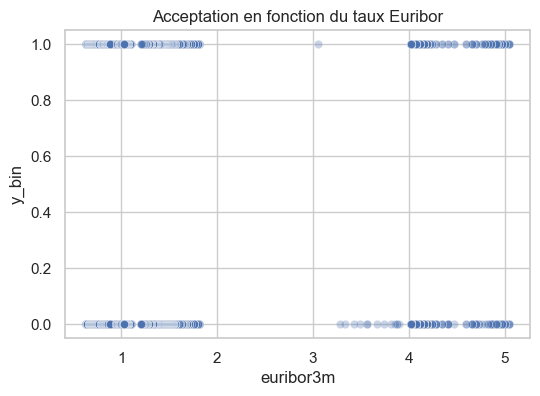

In [52]:
plt.figure(figsize=(6,4))
sns.scatterplot(data=df, x='euribor3m', y='y_bin', alpha=0.3)
plt.title("Acceptation en fonction du taux Euribor")
plt.show()


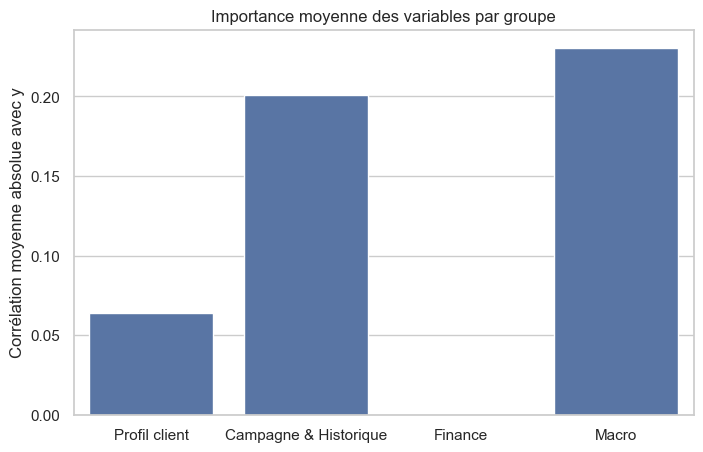

In [53]:
groups = {
    "Profil client": profil_client,
    "Campagne & Historique": campagne_historique,
    "Finance": finance,
    "Macro": ind_macro
}

mean_target = {}

for name, cols in groups.items():
    # on calcule la corrélation moyenne entre y_bin et les colonnes numériques du groupe
    subset = df[cols].select_dtypes(include='number')
    mean_target[name] = subset.corrwith(df['y_bin']).abs().mean()

plt.figure(figsize=(8,5))
sns.barplot(x=list(mean_target.keys()), y=list(mean_target.values()))
plt.title("Importance moyenne des variables par groupe")
plt.ylabel("Corrélation moyenne absolue avec y")
plt.show()
